# 08 — Top Customers by Revenue
Rank the top 20 highest-value customers and visualise their order frequency and profitability.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("08 — Top Customers by Revenue")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 17:02:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ready.


## Query

In [2]:
top_cust = spark.sql('''
    SELECT
        c.customer_name, c.segment,
        COUNT(DISTINCT o.order_id)                             AS total_orders,
        ROUND(SUM(oi.sales),  2)                               AS total_sales,
        ROUND(SUM(oi.profit), 2)                               AS total_profit,
        ROUND(SUM(oi.sales) / COUNT(DISTINCT o.order_id), 2)   AS avg_order_value
    FROM customers c
    JOIN orders      o  ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id    = oi.order_id
    GROUP BY c.customer_name, c.segment ORDER BY total_sales DESC LIMIT 20
''').toPandas()
print(top_cust[["customer_name","segment","total_sales","total_profit"]].head(10))

        customer_name      segment  total_sales  total_profit
0         Sean Miller  Home Office     25043.05      -1980.74
1        Tamara Chand    Corporate     19052.22       8981.32
2        Raymond Buch     Consumer     15117.34       6976.10
3        Tom Ashbrook  Home Office     14595.62       4703.79
4       Adrian Barton     Consumer     14473.57       5444.81
5        Ken Lonsdale     Consumer     14175.23        806.86
6        Sanjit Chand     Consumer     14142.33       5757.41
7        Hunter Lopez     Consumer     12873.30       5622.43
8        Sanjit Engle     Consumer     12209.44       2650.68
9  Christopher Conant     Consumer     12129.07       2177.05


## Visualisation

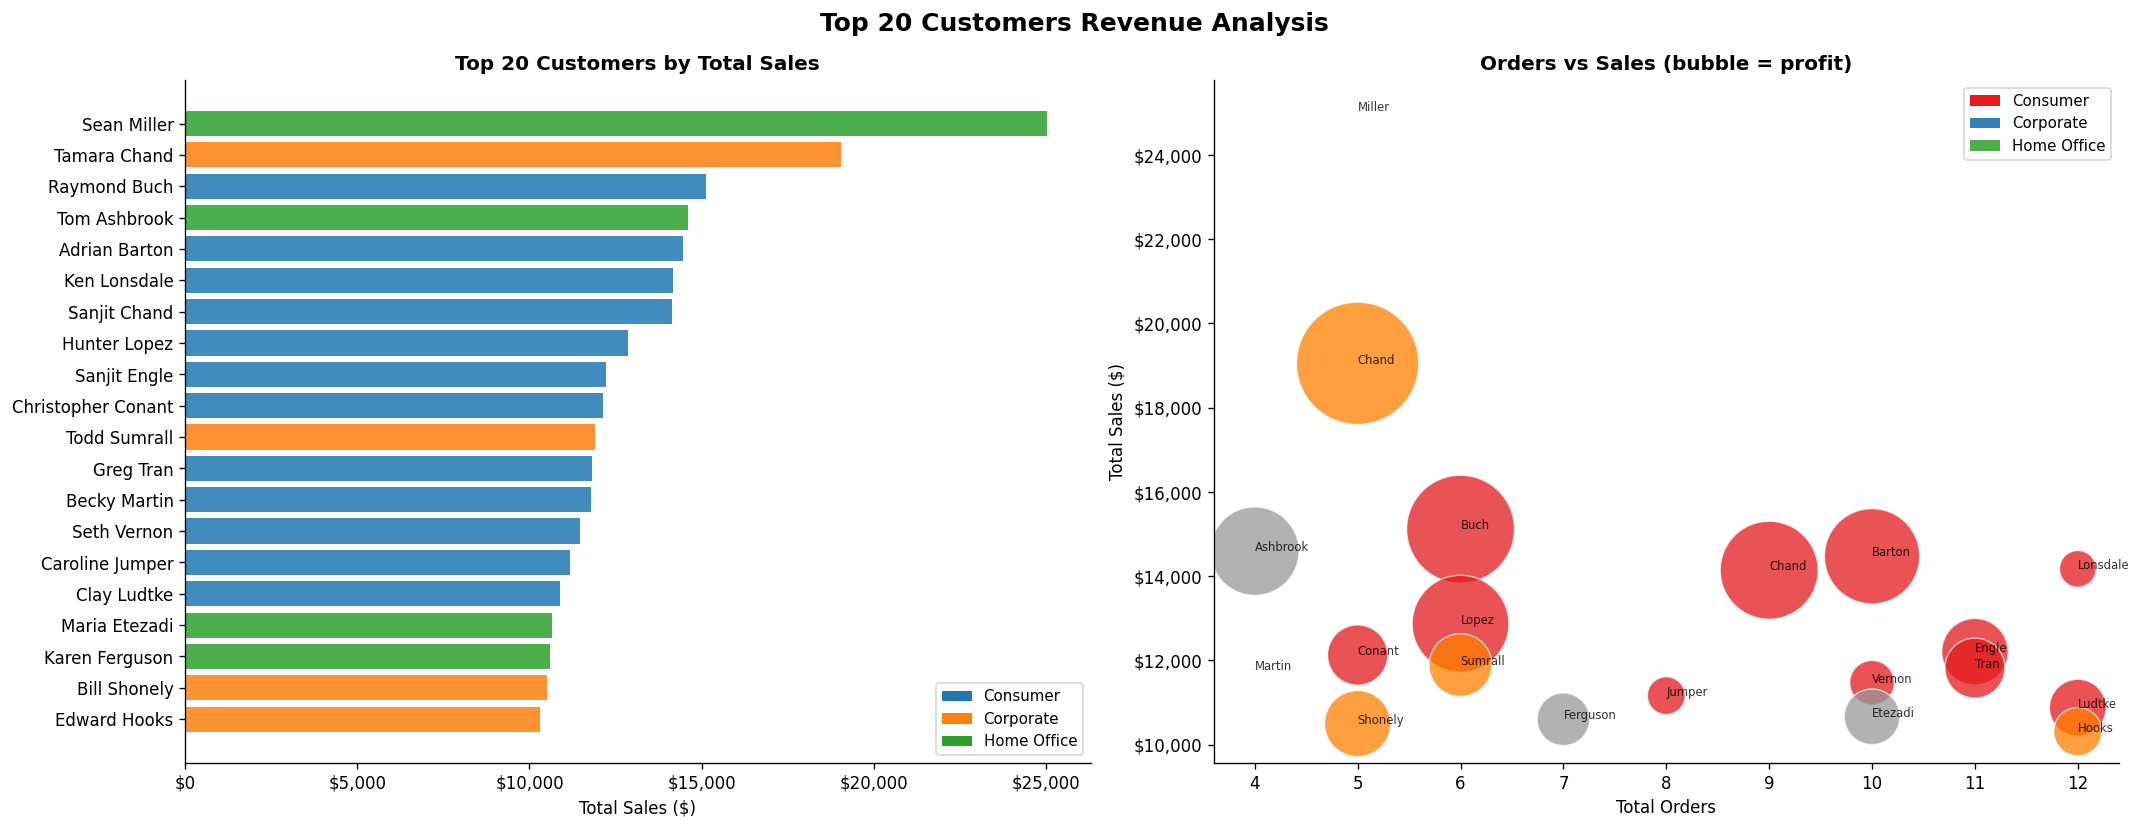

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/08_top_customers.png


In [3]:
from matplotlib.patches import Patch
seg_c = {"Consumer":"#1f77b4","Corporate":"#ff7f0e","Home Office":"#2ca02c"}
c_list = [seg_c.get(s,"#999") for s in top_cust["segment"]]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

short = [n[:30]+"…" if len(n)>30 else n for n in top_cust["customer_name"]]
axes[0].barh(short[::-1], top_cust["total_sales"][::-1], color=c_list[::-1], alpha=0.85)
axes[0].set_title("Top 20 Customers by Total Sales", fontweight="bold"); axes[0].set_xlabel("Total Sales ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[0].legend(handles=[Patch(facecolor=v,label=k) for k,v in seg_c.items()], fontsize=9)

seg_num = {"Consumer":0,"Corporate":1,"Home Office":2}
sc = axes[1].scatter(top_cust["total_orders"], top_cust["total_sales"],
                     s=top_cust["total_profit"].clip(lower=1)*0.6,
                     c=[seg_num.get(s,0) for s in top_cust["segment"]],
                     cmap="Set1", alpha=0.75, edgecolors="white", linewidth=0.8)
for _,row in top_cust.iterrows():
    axes[1].annotate(row["customer_name"].split()[-1],
                     (row["total_orders"], row["total_sales"]), fontsize=7, alpha=0.8)
axes[1].set_xlabel("Total Orders"); axes[1].set_ylabel("Total Sales ($)")
axes[1].set_title("Orders vs Sales (bubble = profit)", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[1].legend(handles=[Patch(facecolor=list(plt.cm.Set1.colors)[:3][i],label=k)
                         for k,i in seg_num.items()], fontsize=9)

plt.suptitle("Top 20 Customers Revenue Analysis", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/08_top_customers.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/08_top_customers.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
